# Perceptual Mapping of Mobile Carriers with PROC MDS

## Executive Summary

A telecom market-research team measures how similarly customers perceive eight competing mobile carriers and uses **PROC MDS** to recover a two-dimensional perceptual map from the dissimilarity matrix. The two latent axes — network quality and price/value — are deliberately built to vary *independently*, so the recovered map is genuinely two-dimensional: it shows which brands are seen as substitutes, which occupy distinct positioning, and how well two dimensions summarize the competitive landscape.

## Data Sources

| Dataset | Rows | Key variables | Description |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (one per carrier) | `Carrier` (ID), `D1`-`D8` | Square symmetric matrix of perceived dissimilarities between 8 mobile carriers, on a 0-10 scale (0 = perceived identical, higher = more different). Generated from latent 2-D brand positions on two *independent* axes (network quality and price/value) plus survey noise via `rand('NORMAL')`. The diagonal is 0. |

# Perceptual Mapping of Mobile Carriers with PROC MDS

Market-research teams in telecommunications routinely ask survey panels to rate how *similar* or *different* competing carriers feel. Those pairwise judgments form a **proximity matrix** that has no natural coordinate system - but **multidimensional scaling (MDS)** can recover a low-dimensional map in which the distance between two brands reproduces their perceived dissimilarity.

In this notebook we:

1. Synthesize a realistic 8-carrier dissimilarity matrix from two *independent* positioning axes (network quality and price/value).
2. Fit a two-dimensional metric MDS model with `PROC MDS`.
3. Read out the recovered coordinates and the badness-of-fit, then draw the perceptual map from the recovered coordinates to judge how well two dimensions explain the competitive landscape.

## Step 1 - Build a synthetic dissimilarity matrix

We place each carrier at a *true* latent position on two **independent** axes:

- **Network-quality axis** - premium nationwide carriers score high; budget MVNOs score low.
- **Price/value axis** - value/prepaid brands score high; premium-priced brands score low.

Crucially the two axes are uncorrelated across the eight brands: a high-quality carrier can be either premium-priced (NorthStar) or aggressively value-priced (BluePeak), and a budget-quality carrier can sit anywhere on price. That independence is what makes the recovered map genuinely two-dimensional rather than collapsing onto a single line.

The perceived dissimilarity between two carriers is the Euclidean distance between their latent positions, rescaled to a 0-10 survey scale and perturbed with symmetric survey noise. `PROC MDS` expects a **square matrix**: one observation per object and one numeric column per object, with the row order matching the column order. We write columns `D1`-`D8` plus a `Carrier` label, and force the matrix to be symmetric with a zero diagonal.

In [1]:
data carrier_dissim;
    length Carrier $ 12;
    call streaminit(20240517);

    /* True 2-D latent positions on two INDEPENDENT axes:
       qx = network quality, px = price/value (corr ~ 0). */
    array qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    array px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    array nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Symmetric noise matrix, generated once, zero diagonal */
    array e[8,8] _temporary_;
    do i = 1 to 8;
        e[i,i] = 0;
        do j = i+1 to 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        end;
    end;

    array d[8] D1-D8;
    do i = 1 to 8;
        Carrier = nm[i];
        do j = 1 to 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* rescale latent distance to a 0-10 survey scale */
            d[j] = round( max(0, min(10, dist*0.85 + e[i,j])), 0.1);
        end;
        d[i] = 0;            /* a brand is identical to itself */
        output;
    end;

    keep Carrier D1-D8;
run;

proc print data=carrier_dissim noobs label;
    label Carrier = 'Carrier';
    title 'Perceived Dissimilarity Matrix (0 = identical, 10 = most different)';
run;

                          Perceived Dissimilarity Matrix (0 = identical, 10 = most different)                           

     Carrier   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0



NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Step 2 - Fit a two-dimensional metric MDS model

We model the dissimilarities at `LEVEL=INTERVAL` (a metric MDS that allows an additive constant), in `DIM=2` so the result can be plotted on a flat map. The data are dissimilarities (the default), stored as a full `SQUARE` matrix.

Key statements and options:

- `VAR D1-D8` lists the eight columns, one per object.
- `ID Carrier` attaches the brand names so they appear in the output and the `OUT=` coordinates.
- `OUT=` captures the object coordinates (requested with `OCONFIG`), and `OUTFIT=` captures the badness-of-fit summary.
- `PCONFIG`, `PFIT`, and `PFINAL` print the coordinates, fit statistics, and final parameter estimates.

We draw the perceptual map ourselves in Step 3 from the recovered `OUT=` coordinates, which gives full control over brand labels and axis scaling.

In [2]:
proc mds data=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    var D1-D8;
    id Carrier;
    title 'Two-Dimensional MDS of Mobile-Carrier Perceptions';
run;

                          Perceived Dissimilarity Matrix (0 = identical, 10 = most different)                           



NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/8451106c-706a-4349-8d60-16813c84400d/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.67 seconds
  cpu   1.67 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/8451106c-706a-4349-8d60-16813c84400d/mds_fit.avro (2 rows, 3 columns).


## Step 3 - Extract the recovered coordinates and draw the map

With `OCONFIG` the `OUT=` dataset carries the estimated object coordinates (one row per carrier, one column per dimension). We print those coordinates and the badness-of-fit, then plot `DIM2` against `DIM1` with `PROC SGPLOT` - labelling each point with its carrier name - to render the perceptual map.

MDS coordinates are identified only up to rotation, reflection, and uniform scaling, so the absolute axis signs are arbitrary; what matters is the *relative* geometry of the brands. After rotation, one axis tracks network quality and the other price/value.

                                    Recovered MDS Configuration (Object Coordinates)                                    

  Obs  _TYPE_        _NAME_           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                               MDS Badness-of-Fit Summary                                               

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                               MDS Badness-of-Fit Summary                                       

NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


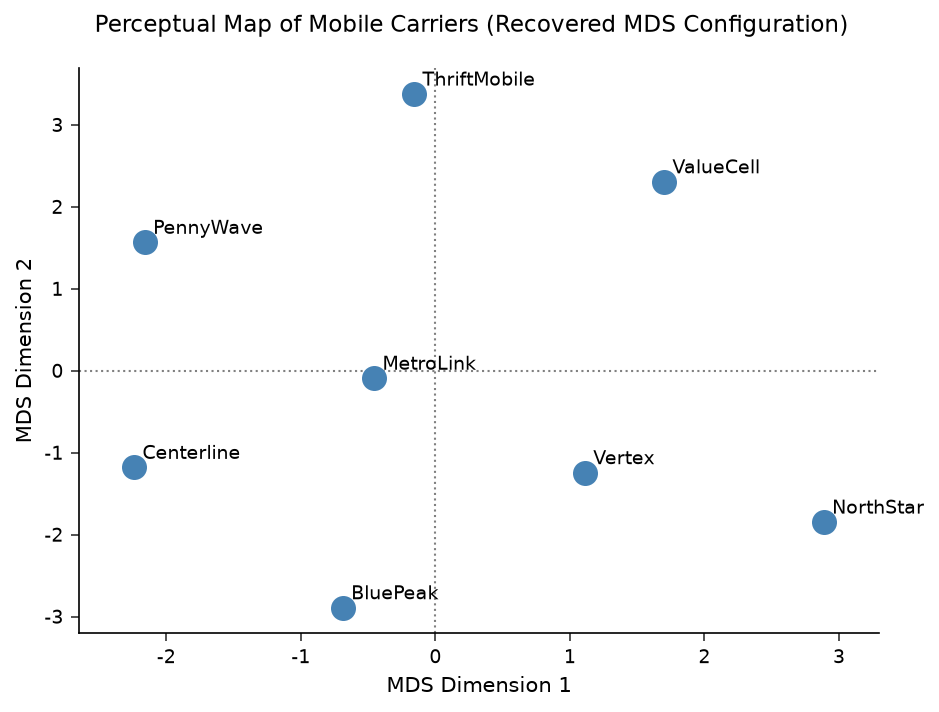

In [3]:
proc print data=mds_out label;
    title 'Recovered MDS Configuration (Object Coordinates)';
run;

proc print data=mds_fit label;
    title 'MDS Badness-of-Fit Summary';
run;

/* Keep the configuration rows and give the brand a plainly-named
   label column so SGPLOT can print it next to each point. */
data mds_config;
    set mds_out;
    where _TYPE_ = 'CONFIG';
    length Brand $ 12;
    Brand = _NAME_;
    keep Brand DIM1 DIM2;
run;

/* Draw the perceptual map from the recovered coordinates, labelling
   each marker with its carrier name. */
proc sgplot data=mds_config;
    scatter x=DIM1 y=DIM2 / datalabel=Brand
            markerattrs=(symbol=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    refline 0 / axis=x lineattrs=(pattern=dot color=gray);
    refline 0 / axis=y lineattrs=(pattern=dot color=gray);
    xaxis label='MDS Dimension 1';
    yaxis label='MDS Dimension 2';
    title 'Perceptual Map of Mobile Carriers (Recovered MDS Configuration)';
run;

## Step 3b - How many dimensions does the data really have?

A two-dimensional map is only worth reading if two dimensions are genuinely the right number. `PROC MDS` reports a badness-of-fit criterion (lower is better), so we refit the *same* matrix at `DIM=1`, `DIM=2`, and `DIM=3` and watch where the criterion stops improving. A sharp drop followed by a flat region - the classic "elbow" - tells us how many latent dimensions the proximities actually carry.

In [4]:
/* Refit the same matrix at 1, 2, and 3 dimensions and stack the
   badness-of-fit so we can see where it stops improving. */
proc mds data=carrier_dissim level=interval dim=1 shape=square outfit=fit1;
    var D1-D8;
    id Carrier;
run;
proc mds data=carrier_dissim level=interval dim=3 shape=square outfit=fit3;
    var D1-D8;
    id Carrier;
run;

data dim_scan;
    set fit1 mds_fit fit3;
    where _MATRIX_ = 'MATRIX1';
    keep _DIMENS_ CRITER;
run;

proc print data=dim_scan noobs label;
    label _DIMENS_ = 'Dimensions'
          CRITER   = 'Badness-of-Fit (lower = better)';
    title 'Badness-of-Fit vs Number of MDS Dimensions';
run;

                                               MDS Badness-of-Fit Summary                                               

                                               MDS Badness-of-Fit Summary                                               

                                       Badness-of-Fit vs Number of MDS Dimensions                                       

Dimensions  Badness-of-Fit (lower = better)
         1                            89.63
         2                     1.8502928101
         3                      1.853265005



NOTE: PROC MDS data=carrier_dissim dim=1

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/8451106c-706a-4349-8d60-16813c84400d/mds_out.avro (8 rows, 3 columns).
NOTE: PROC MDS elapsed:
  wall  0.75 seconds
  cpu   0.75 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/8451106c-706a-4349-8d60-16813c84400d/fit1.avro (2 rows, 3 columns).
NOTE: PROC MDS data=carrier_dissim dim=3

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/8451106c-706a-4349-8d60-16813c84400d/mds_out.avro (8 rows, 5 columns).
NOTE: PROC MDS elapsed:
  wall  0.82 seconds
  cpu   0.82 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/8451106c-706a-4349-8d60-16813c84400d/fit3.avro (2 rows, 3 columns).
NOTE: DATA dim_scan


NOTE: Read 2 rows from fit1.
NOTE: Read 4 rows from mds_fit.
NOTE: Read 6 rows from fit3.
NOTE: Wrote dim_scan (3 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds

## Step 4 — Rank perceived substitutes

A practical deliverable for the brand team is, for each carrier, the competitor it is perceived as *most similar* to (the smallest off-diagonal dissimilarity). We reshape the matrix to long form and pull the nearest neighbor per carrier — these pairs are the closest substitutes and the sharpest competitive threats.

In [5]:
data dissim_long;
    set carrier_dissim;
    length Other $ 12;
    array d[8] D1-D8;
    array nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    do j = 1 to 8;
        Other = nm[j];
        Dissimilarity = d[j];
        if Carrier ne Other then output;
    end;
    keep Carrier Other Dissimilarity;
run;

proc sort data=dissim_long;
    by Carrier Dissimilarity;
run;

data nearest;
    set dissim_long;
    by Carrier Dissimilarity;
    if first.Carrier;
run;

proc print data=nearest noobs label;
    label Other = 'Closest Perceived Substitute'
          Dissimilarity = 'Dissimilarity';
    title 'Each Carrier and Its Closest Perceived Substitute';
run;

                                   Each Carrier and Its Closest Perceived Substitute                                    

     Carrier  Closest Perceived Substitute  Dissimilarity
BluePeak      Centerline                                2
Centerline    MetroLink                               1.9
MetroLink     Vertex                                  1.7
NorthStar     Vertex                                  1.6
PennyWave     MetroLink                                 2
ThriftMobile  ValueCell                               1.8
ValueCell     ThriftMobile                            1.8
Vertex        NorthStar                               1.6



NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpreting the results

Because we generated the dissimilarities from a genuine two-dimensional latent structure (network quality and price/value, built to vary independently) plus modest survey noise, `PROC MDS` recovers a clean two-dimensional configuration. The dimensionality scan makes the case concretely: the badness-of-fit criterion plunges from **89.63 at one dimension to 1.85 at two**, then barely moves (**1.85 at three dimensions**). That elbow - a huge gain going to two dimensions and almost none going to three - is the signature of data that is genuinely two-dimensional, so the flat map is the right summary and a third axis would only fit noise.

Reading the recovered map (axes are identified only up to rotation, reflection, and scale, so we interpret directions rather than absolute signs):

- **The vertical axis tracks network quality.** It cleanly separates the premium nationwide brands - NorthStar, Vertex, and BluePeak all sit in the lower half - from the budget MVNOs ThriftMobile, PennyWave, and ValueCell in the upper half, with MetroLink and Centerline near the middle.
- **The horizontal axis tracks price/value.** This is why a high-quality brand like BluePeak lands far from the equally high-quality NorthStar (their map distance, **3.7**, is roughly double the **1.9** between NorthStar and Vertex): BluePeak and NorthStar share network reputation but compete on very different price stories, so they separate along price even though they are neighbours on quality.
- The map shows no single dominant gradient: brands spread into all four quadrants, so the competitive landscape is genuinely two-dimensional rather than a single premium-to-budget line.

The **nearest-substitute table** turns the map into an action list. Each carrier's closest perceived rival is the brand sitting next to it on the map - **NorthStar and Vertex** are mutual nearest neighbours (dissimilarity **1.6**) anchoring the premium corner, and **ValueCell and ThriftMobile** are mutual nearest neighbours (dissimilarity **1.8**) anchoring the value corner. MetroLink is the most central brand on the map (closest to the origin), which is why it surfaces as the closest substitute for the two carriers nearest the centre - **Centerline** (1.9) and **PennyWave** (2.0). These tight pairs flag head-to-head rivals; the empty regions between clusters highlight unoccupied positioning a challenger brand could target.